# Carnet 02 : Évaluation Baseline et Crash-Test (Phase 3)
**Auteur :** Kaan BILGIC
**Projet :** Détection d'anomalies IoT par Machine Learning

**Objectif :** Ce script entraîne les modèles (Isolation Forest et Autoencoder) sur le trafic normal, puis procède à une attaque massive (Crash-Test) pour démontrer l'angle mort de l'IA.
---

In [1]:
import pandas as pd

# Chargement de l'échantillon GitHub (Trafic Normal)
file_path = "../data/sample_Normal_Traffic.csv"
print("Chargement depuis l'échantillon CSV...", flush=True)

df_final = pd.read_csv(file_path, low_memory=False)
print(f"Dataset chargé : {df_final.shape[0]:,} lignes × {df_final.shape[1]} colonnes")

print(f"Dataset chargé : {df_final.shape[0]:,} lignes × {df_final.shape[1]} colonnes")
print(f"   RAM utilisée   : {df_final.memory_usage(deep=True).sum() / 1024**2:.0f} Mo")
print(f"\nRépartition par capteur :")
print(df_final['Source_Sensor'].value_counts().to_string())

Chargement depuis l'échantillon CSV...
Dataset chargé : 150,000 lignes × 64 colonnes
Dataset chargé : 150,000 lignes × 64 colonnes
   RAM utilisée   : 243 Mo

Répartition par capteur :
Source_Sensor
Temperature_and_Humidity    23558
Water_Level                 18252
IR_Receiver                 18158
Soil_Moisture               18038
Sound_Sensor                17856
Distance                    17615
Flame_Sensor                15847
phValue                     15080
Heart_Rate                   3279
Modbus                       2317


In [2]:
## 1. Prétraitement et Normalisation (Création du Terrain Vierge)

from sklearn.preprocessing import StandardScaler
import pandas as pd

print("Début du nettoyage du dataset")

# 1. Liste exhaustive des colonnes textuelles (dont les fameuses IP) à éradiquer
cols_to_drop = [
    'frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
    'arp.src.proto_ipv4', 'http.file_data', 'http.request.uri.query',
    'http.request.method', 'http.referer', 'http.request.full_uri',
    'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport',
    'tcp.dstport', 'udp.port', 'tcp.ack', 'tcp.seq',
    'tcp.ack_raw', 'tcp.seq_raw', 'tcp.checksum', 'icmp.checksum',
    'icmp.seq_le', 'mbtcp.trans_id', 'dns.qry.name.len', 'mqtt.conack.flags',
    'mqtt.msg', 'mqtt.protoname', 'mqtt.topic', 'Attack_label', 'Attack_type',
    'tcp.flags', 'http.content_length', 'mbtcp.len', 'mqtt.topic_len',
    'tcp.connection.syn', 'mqtt.ver', 'http.tls_port', 'mqtt.conflag.cleansess',
    'dns.qry.qu', 'mqtt.proto_len'
]

# 2. Suppression de ces colonnes textuelles
# Note : On GARDE temporairement 'Source_Sensor' à part pour cibler notre attaque plus tard
X_clean_temp = df_final.drop(columns=cols_to_drop, errors='ignore')

# On sépare la colonne 'Source_Sensor' du reste pour ne garder que les maths
capteurs_source = X_clean_temp['Source_Sensor'].copy()
X_clean_maths = X_clean_temp.drop(columns=['Source_Sensor'])

# 3. Forçage strict au format numérique
print("Conversion stricte en valeurs numériques...")
X_clean_num = X_clean_maths.apply(pd.to_numeric, errors='coerce').fillna(0)

print(f"-> Colonnes textuelles supprimées. Nouvelles dimensions : {X_clean_num.shape}")

# 4. Normalisation (StandardScaler) pour mettre à la même échelle
print("Application du StandardScaler ...")
scaler_phase3 = StandardScaler()
X_scaled_array = scaler_phase3.fit_transform(X_clean_num)

# 5. Reconstruction du DataFrame final propre
df_ready_for_attack = pd.DataFrame(X_scaled_array, columns=X_clean_num.columns)

# On réattache le nom des capteurs pour savoir qui on va pirater
df_ready_for_attack['Source_Sensor'] = capteurs_source.values

print("Nettoyage terminé ! Les IP n'existent plus. Le terrain vierge est prêt.")
display(df_ready_for_attack.head(3))

Début du nettoyage du dataset
Conversion stricte en valeurs numériques...
-> Colonnes textuelles supprimées. Nouvelles dimensions : (150000, 23)
Application du StandardScaler ...
Nettoyage terminé ! Les IP n'existent plus. Le terrain vierge est prêt.


,arp.opcode,arp.hw.size,icmp.transmit_timestamp,icmp.unused,http.response,tcp.connection.fin,tcp.connection.rst,tcp.connection.synack,tcp.flags.ack,tcp.len,...,dns.retransmission,dns.retransmit_request,dns.retransmit_request_in,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msg_decoded_as,mqtt.msgtype,mbtcp.unit_id,Source_Sensor
0,-0.020859,-0.026213,0.0,0.0,0.0,-0.363269,-0.394977,-0.077835,-0.022932,-0.160014,...,-0.011812,-0.003652,-0.002582,0.0,0.0,-0.339569,0.0,-0.350037,-0.003652,IR_Receiver
1,-0.020859,-0.026213,0.0,0.0,0.0,-0.363269,-0.394977,-0.077835,-0.022932,-0.160014,...,-0.011812,-0.003652,-0.002582,0.0,0.0,-0.339569,0.0,-0.350037,-0.003652,Temperature_and_Humidity
2,-0.020859,-0.026213,0.0,0.0,0.0,-0.363269,-0.394977,-0.077835,-0.022932,-0.160014,...,-0.011812,-0.003652,-0.002582,0.0,0.0,-0.339569,0.0,-0.350037,-0.003652,Distance


In [3]:
## 2. Entraînement des Modèles Baseline

from sklearn.ensemble import IsolationForest
import tensorflow as tf
from tensorflow.keras import layers, models
import joblib
import numpy as np
import os
import gc

# ---------------------------------------------------------------------------
# 0. Préparation de la matrice d'entraînement
# ---------------------------------------------------------------------------
# .values convertit directement en matrice Numpy, plus léger en RAM que Pandas
X_train_massif = df_ready_for_attack.drop(columns=['Source_Sensor']).values
input_dim = X_train_massif.shape[1]

print(f"-> Matrice d'entraînement prête : {X_train_massif.shape} (Uniquement du trafic Normal)")


# ============================================================================
# 1. ENTRAÎNEMENT DE L'ISOLATION FOREST
# ============================================================================
print("\n--- Début de l'entraînement de l'Isolation Forest ---")

# Le dataset d'entraînement est composé à 100% de trafic sain
iso_forest_v2 = IsolationForest(
    n_estimators=500,
    max_samples=4096,
    contamination='auto', 
    random_state=42,
    n_jobs=-1
)
iso_forest_v2.fit(X_train_massif)
print("Isolation Forest V2 entraînée avec succès !")


# ============================================================================
# 2. ENTRAÎNEMENT DE L'AUTOENCODER (Architecture symétrique)
# ============================================================================
print("\n--- Début de l'entraînement de l'Autoencoder (Architecture Profonde) ---")

# symétrique : une couche BN après la 1ère Dense de l'encodeur, et une couche BN après la 1ère Dense du décodeur 
autoencoder_v2 = models.Sequential([
    layers.InputLayer(input_shape=(input_dim,)),

    # --- ENCODEUR ---
    layers.Dense(64, activation='elu'),
    layers.BatchNormalization(),        # BN stabilisatrice côté encodeur
    layers.Dense(32, activation='elu'),
    layers.Dense(16, activation='elu'),

    # --- ESPACE LATENT (goulot d'étranglement) ---
    layers.Dense(8, activation='elu'),

    # --- DÉCODEUR (miroir strict de l'encodeur) ---
    layers.Dense(16, activation='elu'),
    layers.Dense(32, activation='elu'),
    layers.BatchNormalization(),        # CORRIGÉ : BN symétrique côté décodeur
    layers.Dense(64, activation='elu'),

    # --- SORTIE ---
    layers.Dense(input_dim, activation='linear')
])

autoencoder_v2.compile(optimizer='adam', loss='mae')
autoencoder_v2.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = autoencoder_v2.fit(
    X_train_massif, X_train_massif,
    epochs=30,
    batch_size=1024,
    validation_split=0.05,
    callbacks=[early_stopping],
    verbose=1
)
print("Autoencoder V2 entraîné avec succès !")


# ============================================================================
# 3. CALCUL ET SAUVEGARDE DU SEUIL DE DÉTECTION (Anti data-leakage)
# ============================================================================
# on calcule le seuil ici, immédiatement après l'entraînement, sur un
# sous-ensemble de données d'ENTRAÎNEMENT (trafic 100% sain, étiquettes connues).
# Ce seuil est ensuite sauvegardé sur disque pour être rechargé dans le Crash-Test.

print("\n--- Calcul du seuil de détection de l'Autoencoder (sur données d'entraînement) ---")

# On utilise un sous-échantillon pour économiser la RAM (50 000 lignes suffisent)
n_seuil = min(50000, X_train_massif.shape[0])
X_seuil = X_train_massif[:n_seuil]

reconstructions_seuil = autoencoder_v2.predict(X_seuil, batch_size=1024, verbose=0)
mae_seuil = np.mean(np.abs(X_seuil - reconstructions_seuil), axis=1)

# Percentile 95 : on accepte 5% de faux positifs sur le trafic normal
seuil_ae = float(np.percentile(mae_seuil, 95))
print(f"-> Seuil de détection AE fixé à : {seuil_ae:.6f}  (p95 sur {n_seuil:,} trames saines)")


# ============================================================================
# 4. SAUVEGARDE DE TOUS LES ARTEFACTS
# ============================================================================
print("\n--- Sauvegarde des modèles et artefacts V2 ---")

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

try:
    # Isolation Forest
    if_path = os.path.join(model_dir, 'isolation_forest_V2_3M.pkl')
    joblib.dump(iso_forest_v2, if_path)
    print(f"IF V2 sauvegardée       : {if_path}")

    # Autoencoder
    ae_path = os.path.join(model_dir, 'autoencoder_V2_3M.keras')
    autoencoder_v2.save(ae_path)
    print(f"AE V2 sauvegardé        : {ae_path}")

    # Sauvegarde du StandardScaler
    scaler_path = os.path.join(model_dir, 'scaler_phase3.pkl')
    joblib.dump(scaler_phase3, scaler_path)
    print(f"Scaler sauvegardé       : {scaler_path}")

    # Sauvegarde du seuil AE (évite le data leakage dans le Crash-Test)
    seuil_path = os.path.join(model_dir, 'seuil_ae_V2.pkl')
    joblib.dump(seuil_ae, seuil_path)
    print(f"Seuil AE sauvegardé     : {seuil_path}  (valeur : {seuil_ae:.6f})")

except Exception as e:
    print(f"Erreur lors de la sauvegarde : {e}")


# ============================================================================
# 5. NETTOYAGE MÉMOIRE
# ============================================================================
del X_train_massif, X_seuil, reconstructions_seuil, mae_seuil
gc.collect()

print("\nModèles, scaler et seuil sauvegardés. Pipeline prêt pour le Crash-Test.")

-> Matrice d'entraînement prête : (150000, 23) (Uniquement du trafic Normal)

--- Début de l'entraînement de l'Isolation Forest ---
Isolation Forest V2 entraînée avec succès !

--- Début de l'entraînement de l'Autoencoder (Architecture Profonde) ---


C:\Users\Chr\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 23)                  │           1,495 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,959 (35.00 KB)

 Trainable params: 8,767 (34.25 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1372 - val_loss: 0.1288
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0593 - val_loss: 0.0795
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0485 - val_loss: 0.0571
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0428 - val_loss: 0.0473
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0368 - val_loss: 0.0458
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0303 - val_loss: 0.0387
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0286 - val_loss: 0.0324
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0265 - val_loss: 0.0316
Epoch 9/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0254 - val_loss: 0.0305
Epoch 10/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0252 - val_loss: 0.0285
Epoch 11/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0232 - val_loss: 0.0276
Epoch 12/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [4]:
## 3. Le Crash-Test

import pandas as pd
import glob
import os
import numpy as np
import joblib
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# ---------------------------------------------------------------------------
# 0. Chargement des artefacts sauvegardés en Cell 8
# ---------------------------------------------------------------------------
# On charge explicitement le scaler et le seuil depuis disque.
# cellule autonome et reproductible.

model_dir = "../models"

print("--- Chargement des artefacts du pipeline ---")
scaler_phase3  = joblib.load(os.path.join(model_dir, 'scaler_phase3.pkl'))
iso_forest_v2  = joblib.load(os.path.join(model_dir, 'isolation_forest_V2_3M.pkl'))

import tensorflow as tf
autoencoder_v2 = tf.keras.models.load_model(os.path.join(model_dir, 'autoencoder_V2_3M.keras'))

# Le seuil AE est chargé depuis disque.
seuil_ae = joblib.load(os.path.join(model_dir, 'seuil_ae_V2.pkl'))
print(f"-> Seuil AE chargé : {seuil_ae:.6f}  (calibré sur trafic sain d'entraînement)")
print("Tous les artefacts sont chargés.\n")


# ----------------------------------------------------------------------------------
# 1. Chargement des attaques depuis l'échantillon GitHub
# ----------------------------------------------------------------------------------
file_path_dnn = "../data/sample_DNN-EdgeIIoT.csv"
df_mixte = pd.read_csv(file_path_dnn, low_memory=False)

# On isole uniquement les attaques pour le Crash-Test
df_attaques = df_mixte[df_mixte['Attack_type'] != 'Normal'].copy()
print(f"\n-> Total des attaques chargées : {df_attaques.shape[0]} lignes.")
# ---------------------------------------------------------------------------
# 2. Construction du jeu de test mixte
# ---------------------------------------------------------------------------
df_attaques['Ground_Truth'] = -1

# Note : df_final contient le dataset d'entraînement (3M trames saines).
# On tire 100 000 lignes avec une seed différente (99) pour minimiser les doublons.
df_normal_test = df_final.sample(n=100000, random_state=99).copy()
df_normal_test['Ground_Truth'] = 1

df_test_mixte = pd.concat([df_normal_test, df_attaques], ignore_index=True)
y_vrai = df_test_mixte['Ground_Truth'].values
print(f"-> Test Set Mixte créé : {df_test_mixte.shape[0]} lignes "
      f"({(y_vrai == 1).sum():,} normales | {(y_vrai == -1).sum():,} attaques)")


# ---------------------------------------------------------------------------
# 3. Nettoyage et normalisation (pipeline identique à l'entraînement)
# ---------------------------------------------------------------------------
cols_to_drop = [
    'frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
    'arp.src.proto_ipv4', 'http.file_data', 'http.request.uri.query',
    'http.request.method', 'http.referer', 'http.request.full_uri',
    'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport',
    'tcp.dstport', 'udp.port', 'tcp.ack', 'tcp.seq',
    'tcp.ack_raw', 'tcp.seq_raw', 'tcp.checksum', 'icmp.checksum',
    'icmp.seq_le', 'mbtcp.trans_id', 'dns.qry.name.len', 'mqtt.conack.flags',
    'mqtt.msg', 'mqtt.protoname', 'mqtt.topic', 'Attack_label', 'Attack_type',
    'tcp.flags', 'http.content_length', 'mbtcp.len', 'mqtt.topic_len',
    'tcp.connection.syn', 'mqtt.ver', 'http.tls_port', 'mqtt.conflag.cleansess',
    'dns.qry.qu', 'mqtt.proto_len',
    'Source_Sensor', 'Ground_Truth'
]

X_test_clean  = df_test_mixte.drop(columns=cols_to_drop, errors='ignore')
X_test_num    = X_test_clean.apply(pd.to_numeric, errors='coerce').fillna(0)

# On normalise avec le scaler chargé depuis disque
X_test_scaled = scaler_phase3.transform(X_test_num)
print(f"\n-> Matrice de test normalisée : {X_test_scaled.shape}")


# ---------------------------------------------------------------------------
# 4. Évaluation — Isolation Forest V2
# ---------------------------------------------------------------------------
print("\n" + "="*60)
print("ÉVALUATION — ISOLATION FOREST V2")
print("="*60)

y_pred_if = iso_forest_v2.predict(X_test_scaled)

f1_if = f1_score(y_vrai, y_pred_if, pos_label=-1)
print(f"F1-Score (Détection d'attaques) : {f1_if:.4f}")

print("\nMatrice de Confusion IF :")
print("             Prédit Normal | Prédit Attaque")
cm_if = confusion_matrix(y_vrai, y_pred_if, labels=[1, -1])
print(f"  Réel Normal  : {cm_if[0][0]:>10,}  | {cm_if[0][1]:>13,}")
print(f"  Réel Attaque : {cm_if[1][0]:>10,}  | {cm_if[1][1]:>13,}")

# CORRECTION [4] : Rapport complet (précision / rappel / F1 par classe)
print("\nRapport de classification IF :")
print(classification_report(y_vrai, y_pred_if, target_names=['Normal (1)', 'Attaque (-1)']))


# ---------------------------------------------------------------------------
# 5. Évaluation — Autoencoder V2
# ---------------------------------------------------------------------------
print("\n" + "="*60)
print("ÉVALUATION — AUTOENCODER V2")
print("="*60)

reconstructions = autoencoder_v2.predict(X_test_scaled, batch_size=1024, verbose=0)
mae = np.mean(np.abs(X_test_scaled - reconstructions), axis=1)

# Seuil chargé depuis disque — AUCUN accès à y_vrai ici.
# L'ancienne version calculait : seuil = np.percentile(mae[y_vrai == 1], 95)
# ce qui utilise les étiquettes du test
print(f"-> Seuil de détection appliqué : {seuil_ae:.6f}")

y_pred_ae = np.where(mae > seuil_ae, -1, 1)

f1_ae = f1_score(y_vrai, y_pred_ae, pos_label=-1)
print(f"F1-Score (Détection d'attaques) : {f1_ae:.4f}")

print("\nMatrice de Confusion AE :")
print("             Prédit Normal | Prédit Attaque")
cm_ae = confusion_matrix(y_vrai, y_pred_ae, labels=[1, -1])
print(f"  Réel Normal  : {cm_ae[0][0]:>10,}  | {cm_ae[0][1]:>13,}")
print(f"  Réel Attaque : {cm_ae[1][0]:>10,}  | {cm_ae[1][1]:>13,}")

# Rapport complet
print("\nRapport de classification AE :")
print(classification_report(y_vrai, y_pred_ae, target_names=['Normal (1)', 'Attaque (-1)']))

# Distribution des erreurs de reconstruction
print(f"\nDistribution MAE sur le test set :")
print(f"  Trames normales  → MAE moy : {mae[y_vrai ==  1].mean():.6f} | p95 : {np.percentile(mae[y_vrai ==  1], 95):.6f}")
print(f"  Trames attaques  → MAE moy : {mae[y_vrai == -1].mean():.6f} | p95 : {np.percentile(mae[y_vrai == -1], 95):.6f}")

print("\nCrash-test terminé !")

--- Chargement des artefacts du pipeline ---
-> Seuil AE chargé : 0.023380  (calibré sur trafic sain d'entraînement)
Tous les artefacts sont chargés.


-> Total des attaques chargées : 40726 lignes.
-> Test Set Mixte créé : 140726 lignes (100,000 normales | 40,726 attaques)

-> Matrice de test normalisée : (140726, 23)

ÉVALUATION — ISOLATION FOREST V2
F1-Score (Détection d'attaques) : 0.2940

Matrice de Confusion IF :
             Prédit Normal | Prédit Attaque
  Réel Normal  :     91,940  |         8,060
  Réel Attaque :     32,320  |         8,406

Rapport de classification IF :
              precision    recall  f1-score   support

  Normal (1)       0.51      0.21      0.29     40726
Attaque (-1)       0.74      0.92      0.82    100000

    accuracy                           0.71    140726
   macro avg       0.63      0.56      0.56    140726
weighted avg       0.67      0.71      0.67    140726


ÉVALUATION — AUTOENCODER V2
-> Seuil de détection appliqué : 0.023380
F1-Score (Dét

Graphique sauvegardé : ../images/crash_test_resultats.png


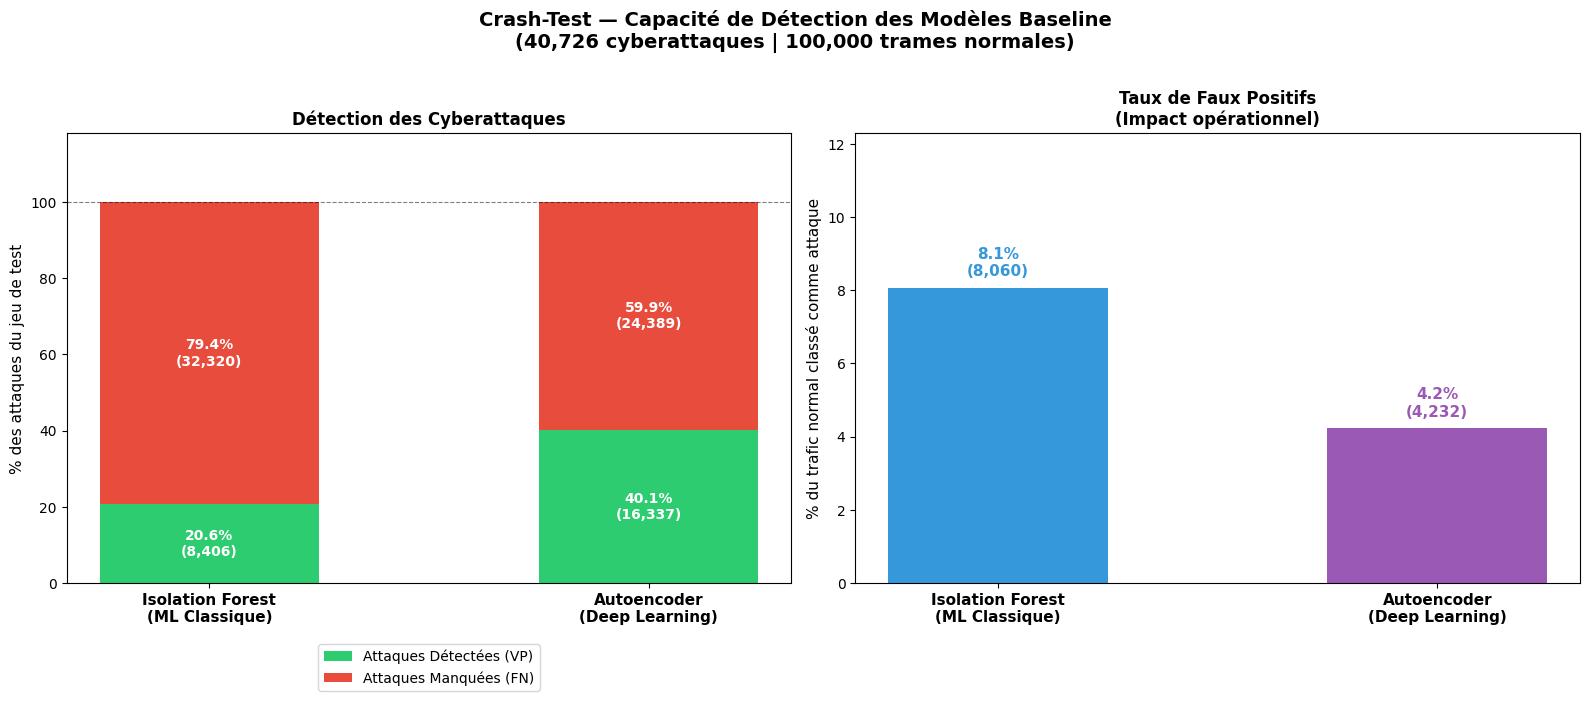


SYNTHÈSE — RÉSULTATS DU CRASH-TEST (ANGLE MORT DÉMONTRÉ)

  Isolation Forest
    Rappel (détection)   : 20.6%  (8,406 / 40,726 attaques trouvées)
    Faux Négatifs        : 79.4%  (32,320 attaques manquées — l'angle mort)
    Taux de FP           : 8.1%  (8,060 normales classées à tort)
    Précision            : 51.1%

  Autoencoder
    Rappel (détection)   : 40.1%  (16,337 / 40,726 attaques trouvées)
    Faux Négatifs        : 59.9%  (24,389 attaques manquées — l'angle mort)
    Taux de FP           : 4.2%  (4,232 normales classées à tort)
    Précision            : 79.4%

CONCLUSION POUR LE RAPPORT :
  Privés de leurs variables textuelles (IP, payloads), les deux modèles
  révèlent un angle mort structurel sur la détection d'attaques furtives.
  L'Isolation Forest manque 79.4% des attaques et l'Autoencoder
  59.9%.



In [5]:
# Cellule : Visualisation des résultats du Crash-Test 

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# ---------------------------------------------------------------------------
# 1. Extraction dynamique des résultats depuis les variables de Cell 9
# ---------------------------------------------------------------------------
# Isolation Forest
vn_if = cm_if[0][0]   # Vrais Négatifs  (normales bien classées)
fp_if = cm_if[0][1]   # Faux Positifs   (normales classées attaque)
fn_if = cm_if[1][0]   # Faux Négatifs   (attaques manquées)
vp_if = cm_if[1][1]   # Vrais Positifs  (attaques détectées)

# Autoencoder
vn_ae = cm_ae[0][0]
fp_ae = cm_ae[0][1]
fn_ae = cm_ae[1][0]
vp_ae = cm_ae[1][1]

# total_attacks calculé depuis les vraies données
total_attacks = int((y_vrai == -1).sum())
total_normal  = int((y_vrai ==  1).sum())

labels_modeles = ['Isolation Forest\n(ML Classique)', 'Autoencoder\n(Deep Learning)']

detected_counts = [vp_if, vp_ae]
missed_counts   = [fn_if, fn_ae]
fp_counts       = [fp_if, fp_ae]

detected_pc = [vp_if / total_attacks * 100, vp_ae / total_attacks * 100]
missed_pc   = [fn_if / total_attacks * 100, fn_ae / total_attacks * 100]
fp_rate     = [fp_if / total_normal  * 100, fp_ae / total_normal  * 100]

# ---------------------------------------------------------------------------
# 2. Figure principale — Détection des attaques (Vrais Positifs vs Faux Négatifs)
# ---------------------------------------------------------------------------
# On crée deux sous-graphiques côte à côte.
# Gauche : taux de détection des attaques (VP vs FN)
# Droite : taux de faux positifs sur le trafic normal (FP)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    f'Crash-Test — Capacité de Détection des Modèles Baseline\n'
    f'({total_attacks:,} cyberattaques | {total_normal:,} trames normales)',
    fontsize=14, fontweight='bold', y=1.01
)

bar_width = 0.5
r = np.arange(len(labels_modeles))

# --- Graphique gauche : VP vs FN ---
p1 = ax1.bar(r, detected_pc, color='#2ecc71', width=bar_width, label='Attaques Détectées (VP)')
p2 = ax1.bar(r, missed_pc, bottom=detected_pc, color='#e74c3c', width=bar_width, label='Attaques Manquées (FN)')

ax1.set_xticks(r)
ax1.set_xticklabels(labels_modeles, fontweight='bold', fontsize=11)
ax1.set_ylabel('% des attaques du jeu de test', fontsize=11)
ax1.set_title("Détection des Cyberattaques", fontsize=12, fontweight='bold')
ax1.set_ylim(0, 118)
ax1.axhline(100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=1, fontsize=10)

def label_bar(ax, rects, percentages, counts):
    """Affiche % et comptage au centre de chaque segment de barre."""
    for i, rect in enumerate(rects):
        h = rect.get_height()
        if h < 3:   # Segment trop petit : on n'affiche pas pour éviter l'illisibilité
            continue
        y_pos = rect.get_y() + h / 2
        ax.text(
            rect.get_x() + rect.get_width() / 2., y_pos,
            f"{percentages[i]:.1f}%\n({counts[i]:,})",
            ha='center', va='center', color='white', fontweight='bold', fontsize=10
        )

label_bar(ax1, p1, detected_pc, detected_counts)
label_bar(ax1, p2, missed_pc,   missed_counts)

# --- Graphique droite : Taux de Faux Positifs ---
# Les FP sont important en IIoT : chaque fausse alarme peut déclencher un arrêt de production.
colors_fp = ['#3498db', '#9b59b6']
bars_fp = ax2.bar(r, fp_rate, color=colors_fp, width=bar_width)

ax2.set_xticks(r)
ax2.set_xticklabels(labels_modeles, fontweight='bold', fontsize=11)
ax2.set_ylabel('% du trafic normal classé comme attaque', fontsize=11)
ax2.set_title("Taux de Faux Positifs\n(Impact opérationnel)", fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(fp_rate) * 1.4 + 1)

for i, (bar, rate, count) in enumerate(zip(bars_fp, fp_rate, fp_counts)):
    ax2.text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height() + max(fp_rate) * 0.03,
        f"{rate:.1f}%\n({count:,})",
        ha='center', va='bottom', fontweight='bold', fontsize=11, color=colors_fp[i]
    )

plt.tight_layout()

# Sauvegarde locale du graphique
fig_path = "../images/crash_test_resultats.png"
os.makedirs("../images", exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Graphique sauvegardé : {fig_path}")

plt.show()

# ---------------------------------------------------------------------------
# 3. Synthèse textuelle pour le rapport
# ---------------------------------------------------------------------------

print("\n" + "="*65)
print("SYNTHÈSE — RÉSULTATS DU CRASH-TEST (ANGLE MORT DÉMONTRÉ)")
print("="*65)

for nom, vp, fn, fp, tot_a, tot_n in [
    ("Isolation Forest", vp_if, fn_if, fp_if, total_attacks, total_normal),
    ("Autoencoder",      vp_ae, fn_ae, fp_ae, total_attacks, total_normal),
]:
    recall    = vp / tot_a * 100
    fpr       = fp / tot_n * 100
    precision = vp / (vp + fp) * 100 if (vp + fp) > 0 else 0.0
    print(f"\n  {nom}")
    print(f"    Rappel (détection)   : {recall:.1f}%  ({vp:,} / {tot_a:,} attaques trouvées)")
    print(f"    Faux Négatifs        : {fn/tot_a*100:.1f}%  ({fn:,} attaques manquées — l'angle mort)")
    print(f"    Taux de FP           : {fpr:.1f}%  ({fp:,} normales classées à tort)")
    print(f"    Précision            : {precision:.1f}%")

print(f"""
CONCLUSION POUR LE RAPPORT :
  Privés de leurs variables textuelles (IP, payloads), les deux modèles
  révèlent un angle mort structurel sur la détection d'attaques furtives.
  L'Isolation Forest manque {fn_if/total_attacks*100:.1f}% des attaques et l'Autoencoder
  {fn_ae/total_attacks*100:.1f}%.
""")